In [6]:
# estimere model kun på pre-reform eller post-reform data
from Model_class import ModelClass
from Model_estimation import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%reload_ext autoreload
%autoreload 2

In [7]:
model = ModelClass()
model.par.weight = True
model.par.unobs_het = True
model.par.moments_start = 0
model.par

namespace(pre=namespace(w=10000,
                        b1=4000,
                        b2=4000,
                        b3=1600,
                        T1=12,
                        T2=106,
                        T3=110),
          post=namespace(w=10000,
                         b1=3500,
                         b2=3500,
                         b3=1600,
                         T1=12,
                         T2=54,
                         T3=60),
          w=10000,
          b1=4000,
          b2=4000,
          b3=1600,
          T1=12,
          T2=106,
          T3=110,
          kappa=array([ 30.,  50., 100.]),
          gamma=1.0,
          delta=0.8,
          mu=1.5,
          type_share1=0.2,
          type_share2=0.2,
          kappa0=array([ 30.,  50., 100.]),
          gamma0=1.0,
          delta0=0.8,
          mu0=1.1,
          type_share1_0=0.4,
          type_share2_0=0.3,
          kappa0_trans=array([3.40119738, 3.91202301, 4.60517019]),
          gamma0_tra

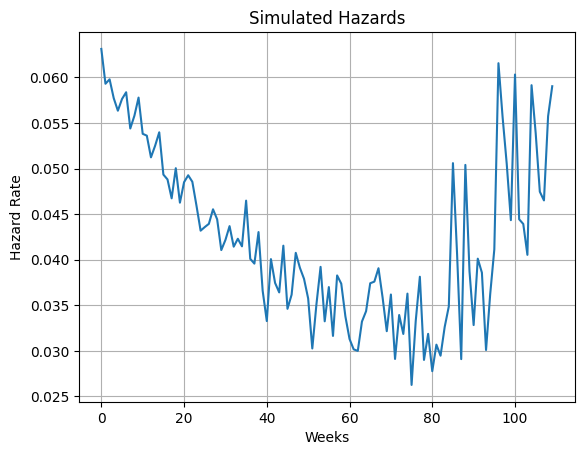

In [8]:
df = pd.read_csv("HR_unobs_pre.csv")

#plot HR_logit in df
plt.plot(df["HR_logit"])
plt.xlabel("Weeks")
plt.ylabel("Hazard Rate")
plt.title("Simulated Hazards")
plt.grid()  
plt.show()

In [9]:
# solve model
smm_estimate(model.par, model.sol, model.data)

(array([ 2.9231466 ,  3.48456428,  4.28968795, -1.8373877 ,  5.07793984,
         0.13617134, -0.76534401,  2.13159444]),
 75.91380584521728,
 True,
 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH')

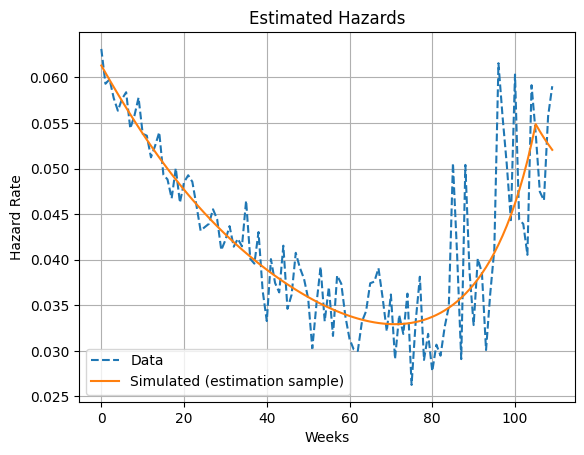

In [10]:
start = model.par.moments_start

# full x-axis for data
x_full = np.arange(model.par.T3)

# truncated x-axis for simulated moments
x_trim = np.arange(start, model.par.T3)

plt.plot(x_full, df["HR_logit"], linestyle='dashed', label='Data')
plt.plot(x_trim, model.sol.moments[start:], label='Simulated (estimation sample)')

plt.xlabel("Weeks")
plt.ylabel("Hazard Rate")
plt.title("Estimated Hazards")
plt.legend()
plt.grid()
plt.show()

In [16]:
model.print_par()

,Parameter,Estimated Value
0,kappa1,18.5997
1,kappa2,32.6082
2,kappa3,72.9437
3,gamma,0.1592
4,delta,0.9938
5,mu,1.1459
6,type_share1,0.3175
7,type_share2,0.6101
8,type_share3,0.0724
